# Fine-Tuning BERT for Sequence Classification (MRPC)

This notebook fine-tunes a pretrained `bert-base-uncased` model on the Microsoft Research Paraphrase Corpus (MRPC) using the Hugging Face `Trainer` API.

The task is binary sequence-pair classification: given two sentences, the model predicts whether they are semantically equivalent.

The workflow covers dataset inspection, BERT tokenization, dynamic padding, model initialization, parameter inspection, metric computation, controlled fine-tuning, validation, training-history analysis, and inference on previously unseen sentence pairs.

**Key Components:**

1. **Dataset Preparation:** Loads the MRPC subset of the GLUE benchmark and inspects its structure and class distribution.
2. **BERT Tokenization:** Converts sentence pairs into the token representation expected by `bert-base-uncased`.
3. **Dynamic Padding:** Pads each batch only to the longest sequence in that batch to avoid unnecessary computation.
4. **Fine-Tuning:** Uses the Hugging Face `Trainer` API with AdamW, warmup, weight decay, gradient accumulation, and mixed-precision training.
5. **Evaluation:** Tracks the GLUE MRPC accuracy and F1 metrics and restores the checkpoint with the best validation F1.
6. **Inference:** Tests the trained model on individual sentence pairs and reports the predicted class and confidence.


## Runtime Note

**Runtime → Restart session** in Google Colab before continuing.


In [ ]:
!pip install -q evaluate

In [ ]:
# Colab's preinstalled torchvision build is frequently ABI-incompatible with
# the torch/transformers versions pulled in above, which crashes `import transformers`.
# Uninstalling it (and not needing it, since this notebook is text-only) avoids that conflict.
!pip uninstall -y torchvision

In [ ]:
import random
import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


## 1. Loading the MRPC Dataset

MRPC is part of the GLUE benchmark and contains pairs of sentences labeled according to whether they are paraphrases.

The dataset is inspected before training so that the number of examples, available fields, and label distribution are known explicitly.


In [ ]:
raw_datasets = load_dataset("nyu-mll/glue", "mrpc")

print("Dataset structure:")
print(raw_datasets)

print("\nTraining features:")
print(raw_datasets["train"].features)

print("\nTraining samples:", len(raw_datasets["train"]))
print("Validation samples:", len(raw_datasets["validation"]))
print("Test samples:", len(raw_datasets["test"]))

print("\nTraining label distribution:")
print(raw_datasets["train"].to_pandas()["label"].value_counts().sort_index())


## 2. Tokenization with BERT

`bert-base-uncased` uses WordPiece tokenization and expects sentence pairs to be represented as a single token sequence with the appropriate special tokens and segment information.

Truncation is enabled so that examples exceeding BERT's maximum supported sequence length can be handled safely.


In [ ]:
checkpoint = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
    return tokenizer(
        example["sentence1"],
        example["sentence2"],
        truncation=True
    )

tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True
)

print(tokenized_datasets)


## Inspecting a Tokenized Example

A single example is inspected to verify the relationship between the original sentence pair and the generated BERT inputs.

The decoded sequence provides a quick sanity check that the tokenizer is representing the sentence pair as expected.


In [ ]:
sample = tokenized_datasets["train"][0]

print("Sentence 1:", sample["sentence1"])
print("Sentence 2:", sample["sentence2"])
print("Label:", sample["label"])
print("\nInput IDs:", sample["input_ids"])
print("\nDecoded sequence:")
print(tokenizer.decode(sample["input_ids"]))


## 3. Token-Length Analysis

Sequence length affects Transformer memory and computation.

The token lengths are measured before padding so that the dataset's natural sequence-length distribution can be observed. This also motivates dynamic padding: padding every example to a global maximum would introduce unnecessary computation for shorter examples.


In [ ]:
train_lengths = [
    len(input_ids)
    for input_ids in tokenized_datasets["train"]["input_ids"]
]

print("Minimum token length:", min(train_lengths))
print("Maximum token length:", max(train_lengths))
print("Mean token length:", f"{np.mean(train_lengths):.2f}")
print("Median token length:", f"{np.median(train_lengths):.2f}")
print("95th percentile:", f"{np.percentile(train_lengths, 95):.2f}")


## 4. Dynamic Padding

`DataCollatorWithPadding` performs padding at batch construction time rather than padding the complete dataset to one fixed length.

This is particularly useful for Transformer workloads because attention computation scales with sequence length. Reducing unnecessary padding therefore reduces wasted computation and memory.


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

samples = tokenized_datasets["train"][:8]
model_inputs = {
    key: value for key, value in samples.items()
    if key not in ["idx", "sentence1", "sentence2"]
}

batch = data_collator(model_inputs)

# print("Batch keys:", batch.keys())
print("Input IDs shape:", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape:", batch["labels"].shape)


## 5. BERT Sequence Classification Model

The pretrained `bert-base-uncased` encoder is connected to a classification head with two output logits.

The model is initialized from pretrained weights rather than trained from scratch. Fine-tuning then updates the pretrained representation for the MRPC paraphrase-classification task.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model:", checkpoint)
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")


## Inspecting the Classification Head

The final classification layer is inspected explicitly because the pretrained BERT checkpoint was originally trained for masked-language modeling and is being adapted here to a two-class supervised task.


In [ ]:
print(model.classifier)
print("\nNumber of output classes:", model.num_labels)
print("Output labels:", model.config.id2label)


## 6. Evaluation Metrics

MRPC is commonly evaluated using both accuracy and F1.

Accuracy measures the proportion of correctly classified examples, while F1 provides a balance between precision and recall. Because the best checkpoint is selected using F1, the model selection criterion is explicitly aligned with the evaluation objective.


In [ ]:
metric = evaluate.load("glue", "mrpc")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(
        predictions=predictions,
        references=labels
    )

print(metric)


## 7. Training Configuration

The `TrainingArguments` define the optimization and evaluation protocol.

The configuration uses a small learning rate appropriate for BERT fine-tuning, weight decay for regularization, warmup for more stable optimization at the beginning of training, gradient accumulation to increase the effective batch size, and mixed precision when supported by the available GPU.

The best checkpoint is selected according to validation F1 and restored after training.


In [ ]:
training_args = TrainingArguments(
    output_dir="test-trainer",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    save_total_limit=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,
    push_to_hub=False,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    seed=42,
    data_seed=42,
    report_to="none"
)

## 8. Trainer Construction

The `Trainer` coordinates the training loop, evaluation, checkpointing, metric computation, gradient accumulation, and optimizer updates.

The dataset is already tokenized, while dynamic padding is delegated to the data collator so that each batch is padded only as needed.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer ready.")


## 9. Fine-Tuning BERT

The pretrained model is now fine-tuned on the MRPC training split.

Validation evaluation is performed at the end of each epoch, and checkpoints are saved according to the configured strategy.


In [ ]:
train_result = trainer.train()

print("\nTraining completed.")
print("Training runtime:", f"{train_result.metrics['train_runtime']:.2f} seconds")
print("Training samples per second:", f"{train_result.metrics['train_samples_per_second']:.2f}")


## 10. Final Validation Evaluation

After training, the restored best model is evaluated on the MRPC validation split.

The final results include both the GLUE metrics and the evaluation loss.


In [ ]:
eval_results = trainer.evaluate()

print("Final validation results:")
for key, value in eval_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


## 11. Training History

The `Trainer` stores evaluation and training information in its log history.

The validation F1 trajectory is inspected to understand how performance changed across epochs rather than relying only on the final score.


In [ ]:
log_history = trainer.state.log_history

eval_history = [
    entry for entry in log_history
    if "eval_f1" in entry
]

print("Evaluation checkpoints:", len(eval_history))

for entry in eval_history:
    print(
        f"Epoch {entry.get('epoch', 'N/A')}: "
        f"loss={entry.get('eval_loss', float('nan')):.4f}, "
        f"accuracy={entry.get('eval_accuracy', float('nan')):.4f}, "
        f"f1={entry.get('eval_f1', float('nan')):.4f}"
    )


## 12. Validation Learning Curves

The validation metrics are plotted to make the fine-tuning trajectory visible.

This is a lightweight diagnostic rather than a claim of generalization beyond the validation set.


In [ ]:
epochs_eval = [entry["epoch"] for entry in eval_history]
f1_scores = [entry["eval_f1"] for entry in eval_history]
accuracy_scores = [entry["eval_accuracy"] for entry in eval_history]

plt.figure(figsize=(8, 5))
plt.plot(epochs_eval, f1_scores, marker="o", label="Validation F1")
plt.plot(epochs_eval, accuracy_scores, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("MRPC Validation Performance")
plt.legend()
plt.grid(True)
plt.show()


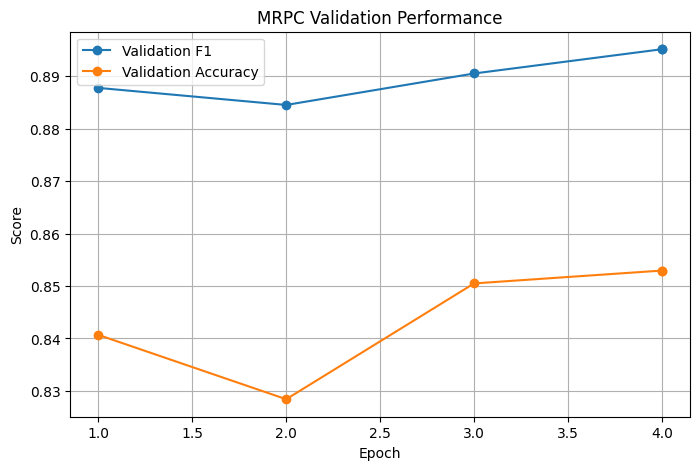

## 13. Inference on Individual Sentence Pairs

The fine-tuned model is now used directly for inference on individual sentence pairs.

The prediction is obtained from the output logits, while softmax converts the logits into class probabilities for an interpretable confidence estimate.


In [ ]:
model = trainer.model
model.eval()

def predict_pair(sentence1, sentence2):
    inputs = tokenizer(
        sentence1,
        sentence2,
        return_tensors="pt",
        truncation=True
    )
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
        probabilities = torch.softmax(logits, dim=-1)
        prediction = probabilities.argmax(dim=-1).item()
        confidence = probabilities[0, prediction].item()

    return prediction, confidence, probabilities.squeeze(0).cpu()

examples = [
    (
        "The company announced a new product today.",
        "A new product was announced by the company today."
    ),
    (
        "The weather is sunny today.",
        "The researchers published a new paper yesterday."
    )
]

for sentence1, sentence2 in examples:
    prediction, confidence, probabilities = predict_pair(sentence1, sentence2)
    print("Sentence 1:", sentence1)
    print("Sentence 2:", sentence2)
    print("Predicted label:", prediction)
    print(f"Confidence: {confidence:.2%}")
    print("Class probabilities:", probabilities.numpy())
    print()


## 14. Inference on Held-Out Test Examples

Finally, the trained model is applied to examples from the MRPC test split.

Because the test split labels are not exposed in the same way as the training and validation examples, this section focuses on the model's actual predictions and confidence rather than calculating a local test metric.


In [ ]:
test_samples = raw_datasets["test"].select(range(8))

model.eval()

for index, example in enumerate(test_samples):
    prediction, confidence, probabilities = predict_pair(
        example["sentence1"],
        example["sentence2"]
    )

    print(f"Example {index + 1}")
    print("Sentence 1:", example["sentence1"])
    print("Sentence 2:", example["sentence2"])
    print("Predicted label:", prediction)
    print(f"Confidence: {confidence:.2%}")
    print()


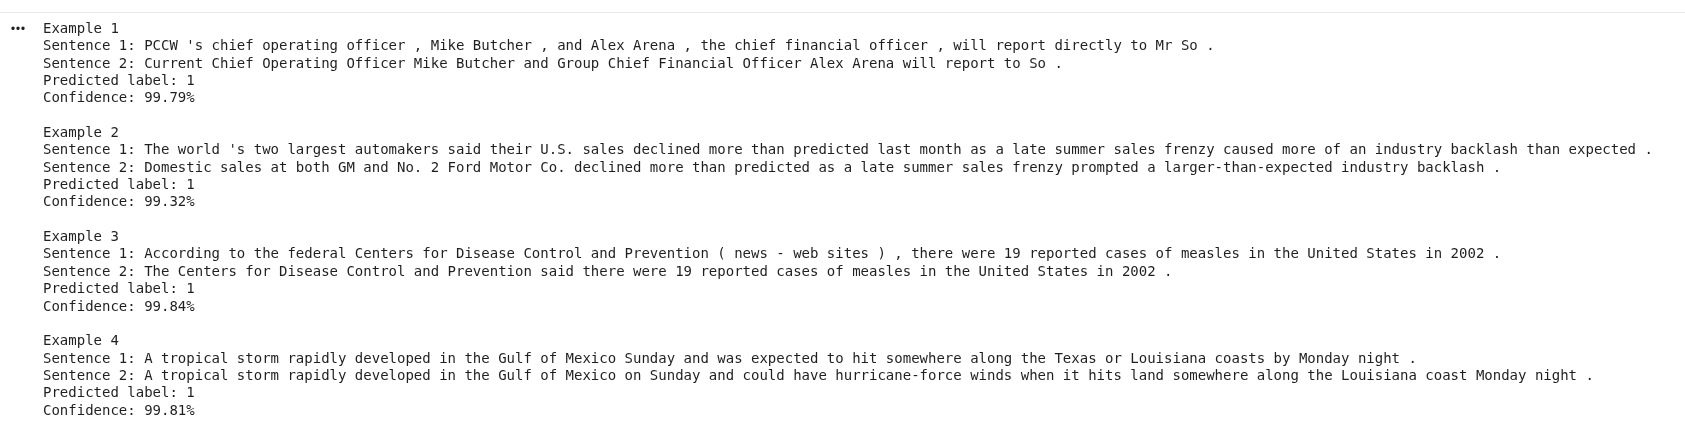

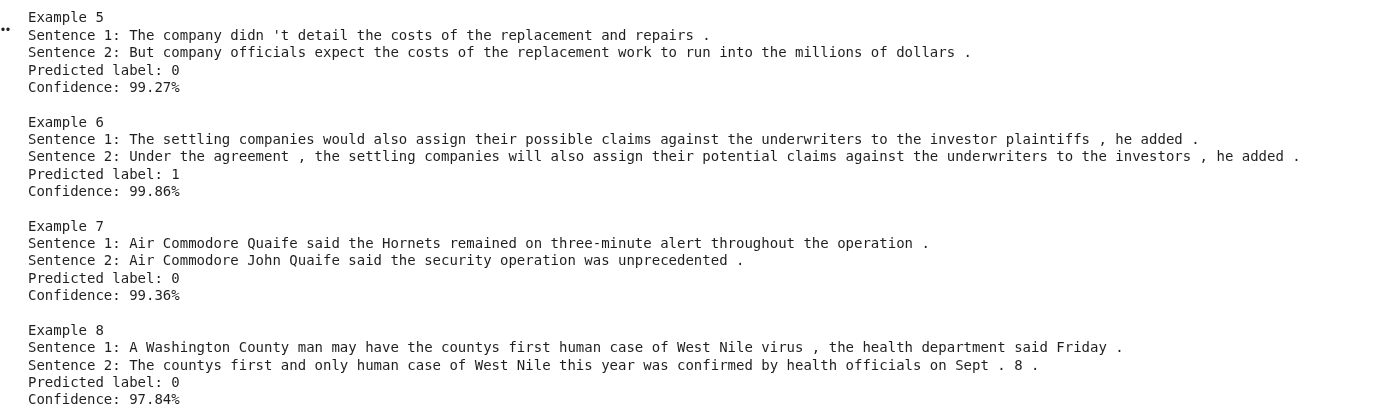

# Research Interpretation & Limitations

This experiment demonstrates a complete BERT fine-tuning workflow for the MRPC paraphrase-classification task using the Hugging Face ecosystem. The results show that the pretrained bert-base-uncased model can be effectively adapted to distinguish whether two sentences have similar meanings.

The model achieved strong validation performance, with Validation F1 remaining around 0.88–0.90 and reaching approximately 0.895 by Epoch 4. Validation accuracy also improved overall, reaching approximately 0.853. This indicates that fine-tuning successfully improved the model's performance on the MRPC validation data.

The use of dynamic padding provides a more efficient training approach by avoiding unnecessary padding of shorter sentence pairs. The training configuration also uses warmup, weight decay, gradient accumulation, and mixed precision to support stable and efficient fine-tuning.

The validation F1 score is used for best-checkpoint selection, ensuring that the selected model is based on its strongest observed validation performance rather than simply the final training epoch.

The individual inference examples further demonstrate the practical use of the trained model. The model produces a predicted class and confidence score for previously unseen sentence pairs, showing how the fine-tuned model can be applied beyond aggregate evaluation metrics.

There are also important limitations. MRPC is a relatively small dataset, and the experiment uses only a single fine-tuning run. Therefore, the reported results do not establish statistical significance or guarantee broad generalization. The experiment also does not include multiple random seeds, hyperparameter sweeps, calibration analysis, or comparisons with alternative pretrained models.

For a stronger evaluation, future work could include multiple training runs, independent test-set evaluation, baseline comparisons, and hyperparameter experiments. These additions would provide greater confidence in the stability and generalization of the observed results.

The complete workflow is:

MRPC → tokenization → dynamic padding → pretrained BERT → supervised fine-tuning → validation evaluation → best-checkpoint selection → inference

Overall, the experiment provides a technically sound demonstration of Transformer fine-tuning, while the validation results indicate good performance with clear opportunities for more rigorous evaluation.